# Session-Level PCA Population Analysis Like in Pani et al.

This notebook demonstrates PCA analysis of MSN cell populations of a single session using the `Session` class.

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import holoviews as hv
import hvplot.pandas
from pathlib import Path
from holoviews import opts
from bokeh.io import output_notebook
from bokeh.palettes import Plasma256
import sys

# Add parent directory to path to import Cell and PopulationAnalyzer
sys.path.append(str(Path.cwd()))

font_dict = {'title': 16, 'labels': 14, 'ticks': 12, 'legend': 12}
hv.opts.defaults(
    hv.opts.Curve(width=800, height=400, tools=['hover'], fontsize=font_dict),
    hv.opts.Image(width=800, height=600, tools=['hover'], cmap='Plasma', colorbar=True, fontsize=font_dict),
)

output_notebook()
hv.extension('bokeh')

print("Imports loaded successfully!")

Loading BokehJS ...

Imports loaded successfully!


In [151]:
# Load MSN cell database
monkey = 'fiona'  # 'yasmin' or 'fiona'

base_path = Path.cwd().parent / 'data' / 'unified_cell_trial_data' 
pickle_file = base_path / f'msn_{monkey}_cell_trial_data.pkl'

cell_df = pd.read_pickle(pickle_file)

In [152]:
cell_df.shape

(770705, 27)

In [153]:
# Add parent directory to path to import Cell and PopulationAnalyzer
sys.path.insert(0, str(Path.cwd().parent))
import importlib
import session_class
import cell_analysis
import pca_helpers
importlib.reload(session_class)
importlib.reload(cell_analysis)
importlib.reload(pca_helpers)
from session_class import Session
from pca_helpers import extract_session_psth_worker
from cell_analysis import Cell, PopulationAnalyzer

print("Cell, PopulationAnalyzer, and Session classes imported successfully!")

Cell, PopulationAnalyzer, and Session classes imported successfully!


In [154]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import StandardScaler

def pca_mat(mat, pca_components=5):
    # scaler = StandardScaler()
    # mat_for_pca = scaler.fit_transform(mat.T)
    mat_for_pca = mat.T
    pca = PCA(n_components=pca_components)
    pca.fit(mat_for_pca)
    return pca

In [155]:
# Select a session to analyze - use session with most cells
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique().sort_values(ascending=False)
best_session_id = session_cell_counts.index[0]

print(f"Using session with most cells: {best_session_id}")
print(f"Number of cells in this session: {session_cell_counts.iloc[0]}")

# Get all data for this session
session_data = cell_df[cell_df['trial_session'] == best_session_id]

# Create Session object
session = Session(session_data, verbose=True)

Using session with most cells: fi211110a
Number of cells in this session: 85
Session fi211110a initialized:
  - Number of cells: 85
  - Total trials: 943
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]


In [156]:
session.config = {
    'alignment_point': 'go_cue',
    # 'alignment_point': 'stop_cue',
    'bin_size': 1,
    'delta': False,
    'epok': [-100, 200],
    'excluded_sessions': ['fi210628', 'fi210629', 'fi210704'],
    'figsize_2d_grid': (7, 19),
    'figsize_3d': (12, 10),
    'figsize_time': (10, 3),
    'min_cells_per_session': 10,
    'min_trials_per_condition': 5,
    'monkey': 'fiona',
    'n_pca_components': 5,
    'n_workers': 6,
    'normalize': False,
    'required_directions': [0, 180],
    'required_trial_types': ['GO', 'STOP', 'CONT'],
    'smooth_ker_size': 15,
    'ssd_number': 2,
    'subtract_average_PSTH': False
}

In [157]:
# analyzer.populate_go_stop_cue()
session.drop_cells_with_missing_trial_type_or_dir_data()

ssd_num = session.config['ssd_number']

stop_trials_mask = (
    (session.data['type'] == 'STOP') &
    (session.data['trial_failed'] == False) &
    (session.data['ssd_number'] == ssd_num)
)

mean_ssd = session.data.loc[stop_trials_mask, 'ssd_len'].apply(
    'mean'
).astype(int)

# Update GO trials
go_trials_mask = session.data['type'] == 'GO'
session.data.loc[go_trials_mask, 'stop_cue'] = session.data.loc[go_trials_mask, 'go_cue'] + mean_ssd


Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.


In [158]:
result = extract_session_psth_worker(
    session_id=session.session_id,
    session_df=session.data,
    epok=session.config['epok'],
    bin_size=session.config['bin_size'],
    delta=session.config['delta'],
    alignment_point=session.config['alignment_point'],
    smooth_ker_size=session.config['smooth_ker_size'],
    normalize=session.config['normalize'],
    compute_average=session.config['subtract_average_PSTH'],
    ssd_number=session.config['ssd_number'],
    split_train_test=False,
    test_fraction=0.5,
    random_state=42
)

In [159]:
result.keys()

dict_keys(['session_id', 'split_mode', 'n_cells_original', 'n_cells', 'n_cells_dropped_ssd', 'go_left', 'go_right', 'stop_left', 'stop_right', 'cell_ids', 'bin_centers'])

In [160]:
left_pca_data_mat = np.hstack((result['go_left'], result['stop_left'])).T
mean_trace = left_pca_data_mat.mean(axis=0, keepdims=True)
left_pca_data_mat = left_pca_data_mat - mean_trace

In [161]:
# left_pca_data_mat = np.hstack((result['go_left'], result['stop_left'])).T
pca_func = TruncatedSVD
# pca_func = PCA
pca = pca_func(n_components=5)
pca.fit(left_pca_data_mat)
pcs_arr = pca.transform(left_pca_data_mat)
pcs_arr.shape

(600, 5)

In [169]:
ex_var_rt = pca.explained_variance_ratio_.copy()
sort_indices = np.argsort(ex_var_rt)[::-1]
ex_var_rt_sorted = ex_var_rt[sort_indices]

ex_var_rt_sorted, sort_indices
pcs_arr = pcs_arr.T[sort_indices].T
ex_var_rt

array([0.2776869 , 0.17344939, 0.10674925, 0.10141162, 0.07246807])

In [163]:
session.drop_cells_with_missing_trial_type_or_dir_data()    

In [164]:
go_pcs = pcs_arr[:300]
stop_pcs = pcs_arr[300:]
go_pcs.shape, stop_pcs.shape

((300, 5), (300, 5))

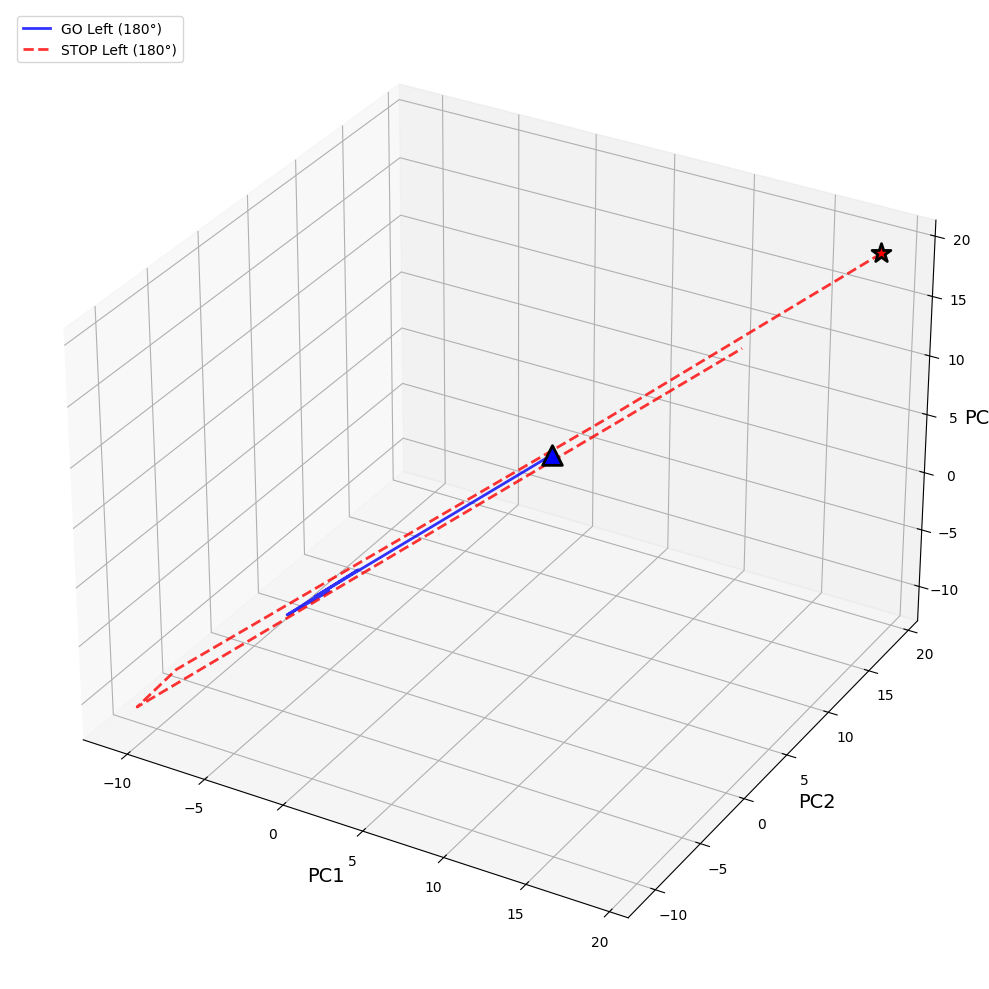

In [165]:
fig = plt.figure(figsize=session.config['figsize_3d'])
ax = fig.add_subplot(111, projection='3d')

# GO trajectories
ax.plot(go_pcs[0, :], go_pcs[1, :], go_pcs[2, :],
        color='blue', linewidth=2, label='GO Left (180°)', alpha=0.8)

# STOP trajectories
ax.plot(stop_pcs[0, :], stop_pcs[1, :], stop_pcs[2, :],
        color='red', linewidth=2, label='STOP Left (180°)', linestyle='dashed', alpha=0.8)

# Start markers
ax.scatter(go_pcs[0, 0], go_pcs[1, 0], go_pcs[2, 0],
            marker='^', s=200, color='blue', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(stop_pcs[0, 0], stop_pcs[1, 0], stop_pcs[2, 0],
            marker='*', s=200, color='red', edgecolors='black', linewidths=2, zorder=5)

# Plot mean SSD point
plot_ssd = True
# if plot_ssd:
#     try:
#         mean_ssd_val = mean_ssd
#         if mean_ssd_val is not None and analyzer.time is not None:
#             ssd_idx = np.argmin(np.abs(analyzer.time - mean_ssd_val))
#             ax.scatter(go_pcs[0, ssd_idx], go_pcs[1, ssd_idx], go_pcs[2, ssd_idx],
#                         marker='o', s=100, color='black', label='Mean SSD', zorder=10)
#             ax.scatter(stop_pcs[0, ssd_idx], stop_pcs[1, ssd_idx], stop_pcs[2, ssd_idx],
#                         marker='o', s=100, color='black', zorder=10)
    
#     except Exception as e:
#         print(f"Warning: Could not plot mean SSD point. {str(e)}")

ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
ax.set_zlabel('PC3', fontsize=14)
title_suffix = ' Pani style '
# ax.set_title(f'3D PC Trajectories{title_suffix} (n={len(analyzer.valid_sessions)} sessions, {analyzer.n_cells} cells)',
        #     fontsize=16)
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()

In [166]:
np.save('../data/PCA_data/pani_go_left_PCs', go_pcs, allow_pickle=False)
# np.save('../data/PCA_data/right_PCs', right_PCs, allow_pickle=False)
np.save('../data/PCA_data/pani_stop_left_PCs', stop_pcs, allow_pickle=False)
# np.save('../data/PCA_data/stop_right_PCs', stop_right_PCs, allow_pickle=False)


In [167]:
time = np.arange(session.config['epok'][0], session.config['epok'][1])
time.shape

(300,)

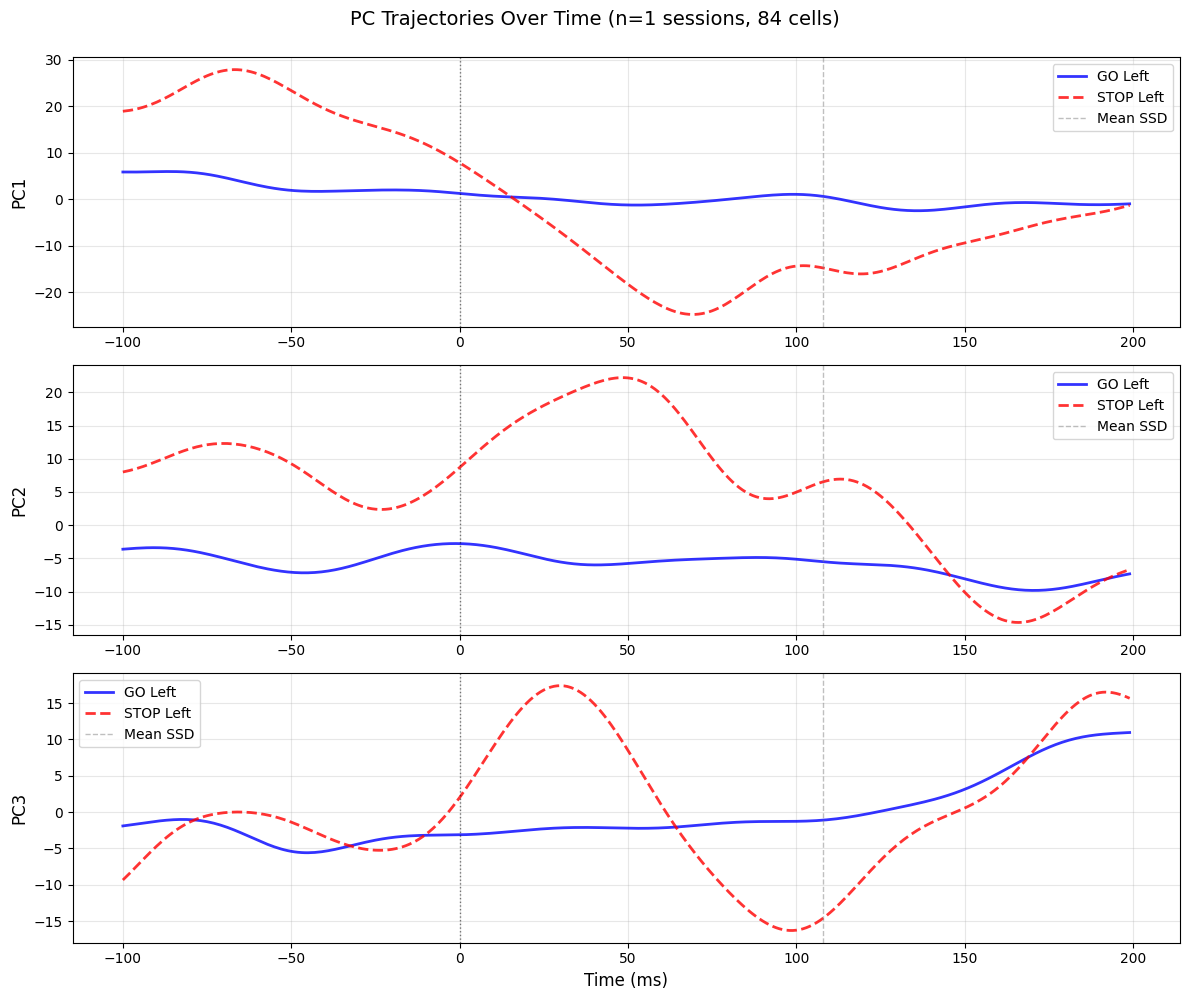

In [168]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# PC1 over time
axes[0].plot(time, go_pcs[:, 0], color='blue', linewidth=2, label='GO Left', alpha=0.8)
axes[0].plot(time, stop_pcs[:, 0], color='red', linewidth=2, label='STOP Left', linestyle='--', alpha=0.8)
axes[0].axvline(x=0, color='black', linestyle=':', linewidth=1, alpha=0.5)

mean_ssd_val = mean_ssd
if plot_ssd and mean_ssd_val is not None:
    axes[0].axvline(x=mean_ssd_val, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Mean SSD')
axes[0].set_ylabel('PC1', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# PC2 over time
axes[1].plot(time, go_pcs[:, 1], color='blue', linewidth=2, label='GO Left', alpha=0.8)
axes[1].plot(time, stop_pcs[:, 1], color='red', linewidth=2, label='STOP Left', linestyle='--', alpha=0.8)
axes[1].axvline(x=0, color='black', linestyle=':', linewidth=1, alpha=0.5)
if plot_ssd and mean_ssd_val is not None:
    axes[1].axvline(x=mean_ssd_val, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Mean SSD')
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# PC3 over time
axes[2].plot(time, go_pcs[:, 2], color='blue', linewidth=2, label='GO Left', alpha=0.8)
axes[2].plot(time, stop_pcs[:, 2], color='red', linewidth=2, label='STOP Left', linestyle='--', alpha=0.8)
axes[2].axvline(x=0, color='black', linestyle=':', linewidth=1, alpha=0.5)
if plot_ssd and mean_ssd_val is not None:
    axes[2].axvline(x=mean_ssd_val, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Mean SSD')
axes[2].set_xlabel('Time (ms)', fontsize=12)
axes[2].set_ylabel('PC3', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'PC Trajectories Over Time (n=1 sessions, {session.n_cells} cells)', 
             fontsize=14, y=0.995)
plt.tight_layout()
# plt.show()